# Generative AI Music Detection Using Convolutional Neural Networks
**Author**: Jeda Krisnell Dionisio

## Setting Up
### Getting the Files
First, I import the libraries that are necessary for my analysis. I use PyTorch for my deep learning library as I have previous experience in it. Along with the libraries, I import my training/test using Google Drive/Colab's mount feature.

In [1]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchaudio
import os
import random
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# select GPU if available, CPU otherwise
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# copy files from drive to working directory
!cp -r /content/drive/MyDrive/IP_MUSIC /content/IP_MUSIC

Mounted at /content/drive


In [2]:
# helper function to get the files from the folder to use
def files_to_folder(folder, label):
  files = []
  labels = []
  for filename in os.listdir(folder):
    if filename.lower().endswith(".wav") and not filename.startswith('._'):
      files.append(os.path.join(folder, filename))
      labels.append(label)
  return files, labels

### Splitting Into Train/Test
After prearing the file implemenetation, I use the paths to combine the train and test sets respectively. I can then label if the WAV file is AI-generated or not.

There are four folders in total:

1. `train_fma`: 1360 10-sec WAV files of open-licensed, original music
2. `train_sonics`: 1360 10-sec WAV files of music generated by Suno/Udio
3. `test_fma`: 340 10-sec WAV files of open-licensed, original music
4. `test_sonics`: 340 10-sec WAV files of music generated by Suno/Udio

Total:
- `2720` training files
- `680` testing files

Labels:
- `0`: not AI-generated music
- `1`: AI-generated music

In [3]:
# train paths
train_sonics_path = "/content/IP_MUSIC/train_sonics"
train_fma_path = "/content/IP_MUSIC/train_fma"

# test paths
test_sonics_path = "/content/IP_MUSIC/test_sonics"
test_fma_path = "/content/IP_MUSIC/test_fma"

In [5]:
# train files + labels
train_fma_files, train_fma_labels = files_to_folder(train_fma_path, 0)
train_sonics_files, train_sonics_labels = files_to_folder(train_sonics_path, 1)

# test files + labels
test_fma_files, test_fma_labels = files_to_folder(test_fma_path, 0)
test_sonics_files, test_sonics_labels = files_to_folder(test_sonics_path, 1)

# combine for train and test datasets
## all train files + labels
train_files = train_fma_files + train_sonics_files
train_labels = train_fma_labels + train_sonics_labels

## all test files + labels
test_files = test_fma_files + test_sonics_files
test_labels = test_fma_labels + test_sonics_labels

# sanity check for train and test file lengths
len(train_files), len(test_files)

(2720, 680)

# Waveform Augmentation
I chose to augment the files' waveforms to generalize the detector in hopes for a better accuracy to music that is outside the FMA and SONICS dataset. This would emulate songs that would be uploaded onto streaming platforms.



In [6]:
def augment_waveform(waveform):
    noise = torch.randn_like(waveform) * 0.005
    waveform = waveform + noise
    gain = random.uniform(0.8, 1.2)
    waveform = waveform * gain

    return waveform

### AudioDataset Class
A key aspect is in the AudioDataset class. This class loads and preprocesses audio files for deep learning. This process allows consistency in sampling rates, audio type (this model looks at mono audio), spectrogram conversion, and more. The ten-sec clips were uniformly split into two five-sec clips. Examples for an AI-generated and not AI-generated spectrograms are seen below. These spectrograms are what the AudioCNN are going to work with.

#### AudioDataSet Definition

In [7]:
class AudioDataset(Dataset):
  def __init__(self, audio_files, labels, sr=22050, duration=5, is_train=False):
    self.sr = sr
    self.is_train = is_train
    self.duration = duration
    self.target_samples = sr * duration
    self.spectrogram_transform = torchaudio.transforms.Spectrogram(power=2).to(device)
    self.valid_audio_segments = []
    for i, audio_file in enumerate(audio_files):
      try:
        if os.path.exists(audio_file):
            self.valid_audio_segments.append((audio_file, labels[i], 0))
            self.valid_audio_segments.append((audio_file, labels[i], 1))
      except Exception as e:
        print(f"Error indexing {audio_file}: {e}")

  def __len__(self):
    return len(self.valid_audio_segments)

  def __getitem__(self, idx):
    audio_file, label, segment_idx = self.valid_audio_segments[idx]
    waveform, original_sr = torchaudio.load(audio_file)

    # resample, if needed
    if original_sr != self.sr:
        resampler = torchaudio.transforms.Resample(original_sr, self.sr).to(waveform.device)
        waveform = resampler(waveform)

    # get start and end of clips
    start = segment_idx * self.target_samples
    end = start + self.target_samples

    # where file is shorter than 5 seconds
    if waveform.shape[1] > start:
        waveform = waveform[:, start:end]
    else:
        # if shorter than 5 seconds, silent tensor to be padded
        waveform = torch.zeros((waveform.shape[0], 0))

    # pad/trim for consistent shape
    if waveform.shape[1] < self.target_samples:
        padding = self.target_samples - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif waveform.shape[1] > self.target_samples:
        waveform = waveform[:, :self.target_samples]

    # convert to mono, if needed
    if waveform.shape[0] > 1:
      waveform = torch.mean(waveform, dim = 0, keepdim = True)

    # augment train waveforms
    if self.is_train:
        waveform = augment_waveform(waveform)

    waveform = waveform.to(device)
    spectrogram = self.spectrogram_transform(waveform)
    label = torch.tensor(label, device=device)
    return spectrogram, label

#### Spectrogram Examples

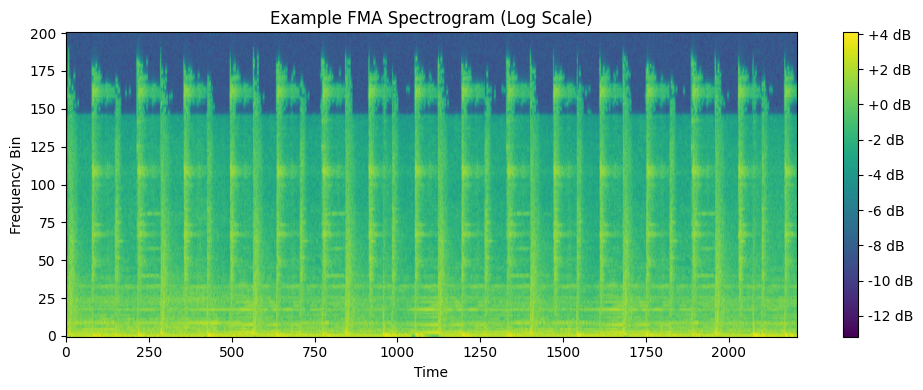

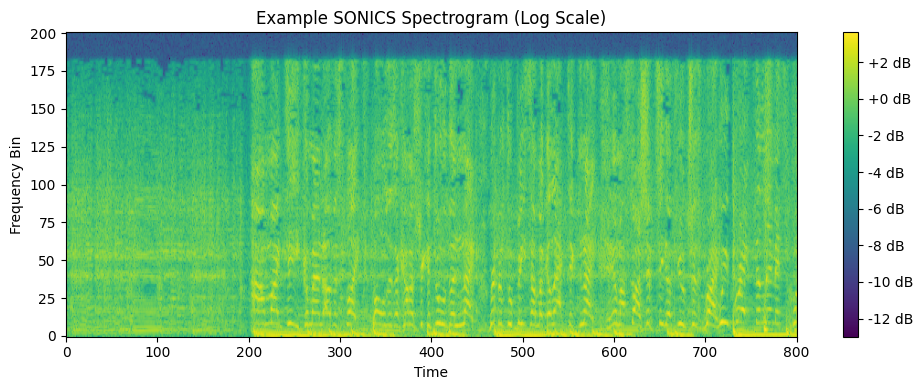

In [9]:
# FMA
ex_fma_waveform, ex_fma_sample_rate = torchaudio.load(train_fma_files[34])
# convert to mono audio, if needed
if ex_fma_waveform.shape[0] > 1:
    ex_fma_waveform = torch.mean(ex_fma_waveform, dim = 0, keepdim = True)

# SONICS
ex_sonics_waveform, ex_sonics_sample_rate = torchaudio.load(train_sonics_files[34])
# convert to mono audio, if needed
if ex_sonics_waveform.shape[0] > 1:
    ex_sonics_waveform = torch.mean(ex_sonics_waveform, dim = 0, keepdim = True)

# transform to spectrograms
spectrogram_transform = torchaudio.transforms.Spectrogram(power = 2).to(device)
ex_fma_spectrogram = spectrogram_transform(ex_fma_waveform.to(device))
ex_sonics_spectrogram = spectrogram_transform(ex_sonics_waveform.to(device))

# FMA song spectrogram plot
plt.figure(figsize = (10, 4))
plt.imshow(ex_fma_spectrogram.squeeze(0).cpu().log10(), aspect = "auto", origin = "lower", cmap= "viridis")
plt.title("Example FMA Spectrogram (Log Scale)")
plt.xlabel("Time")
plt.ylabel("Frequency Bin")
plt.colorbar(format = "%+2.0f dB")
plt.tight_layout()
plt.show()

# SONICS song spectrogram plot
plt.figure(figsize = (10, 4))
plt.imshow(ex_sonics_spectrogram.squeeze(0).cpu().log10(), aspect = "auto", origin = "lower", cmap = "viridis")
plt.title("Example SONICS Spectrogram (Log Scale)")
plt.xlabel("Time")
plt.ylabel("Frequency Bin")
plt.colorbar(format = "%+2.0f dB")
plt.tight_layout()
plt.show()

### Splitting into Train/Validation/Test
To tune and optimize the model during training, I use a validation set. The updated count for each dataset is the following:
- `train_dataset` (64%): 4352 (2176/type)
- `val_dataset` (16%): 1088 (544/type)
- `test_dataset` (20%): 1380 (680/type)

where type is either a non-AI or AI song.

In [10]:
# split training data into training and validation sets
train_files_split, val_files, train_labels_split, val_labels = train_test_split(
    train_files, train_labels, test_size = 0.2, random_state = 34, stratify = train_labels
)

# getting the train/validation/test dataset and loader
train_dataset = AudioDataset(train_files_split, train_labels_split, is_train = True)
val_dataset = AudioDataset(val_files, val_labels, is_train = False)
test_dataset = AudioDataset(test_files, test_labels, is_train = False)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32)

# sanity check for train, valid, and test dataset lengths
print(f"Dataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset sizes: Train: 4352, Val: 1088, Test: 1360


# Convolutional Neural Network
The CNN architecture that I came up with is the following features and hyperparameters:
- 11 total layers
- ReLu activation function
- Max Pooling and Adaptive Average Pooling functions
- Adam optimizer with learning rate scheduler
- Dropout regularization
- Batch Nomalization

In [11]:
class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()

        # BLOCK 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)

        # BLOCK 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(64)

        # BLOCK 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.avg_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = AudioCNN().to(device)

# loss function and optimizer/scheduler
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

## Training

In [12]:
avg_losses = []
avg_val_losses = []
num_epochs = 30
print_freq = 100

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (spectrograms, labels) in enumerate(train_loader, 0):
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        if spectrograms.shape[1] > 1:
            spectrograms = torch.mean(spectrograms, dim=1, keepdim=True)

        optimizer.zero_grad()
        outputs = model(spectrograms)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % print_freq == print_freq - 1:
          avg_loss = running_loss / print_freq
          print(f"[epoch: {epoch}, i: {i:5d}] avg mini-batch training loss: {avg_loss: .3f}")
          avg_losses.append(avg_loss)
          running_loss = 0.0

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for i, (spectrograms, labels) in enumerate(val_loader, 0):
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)

            if spectrograms.shape[1] > 1:
                spectrograms = torch.mean(spectrograms, dim=1, keepdim=True)

            outputs = model(spectrograms)
            loss = loss_func(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    print(f"[epoch: {epoch}] avg validation loss: {avg_val_loss: .3f}\n")
    avg_val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

print("Finished Training.")

[epoch: 0, i:    99] avg mini-batch training loss:  0.619
[epoch: 0] avg validation loss:  0.566

[epoch: 1, i:    99] avg mini-batch training loss:  0.587
[epoch: 1] avg validation loss:  0.641

[epoch: 2, i:    99] avg mini-batch training loss:  0.557
[epoch: 2] avg validation loss:  0.518

[epoch: 3, i:    99] avg mini-batch training loss:  0.554
[epoch: 3] avg validation loss:  0.490

[epoch: 4, i:    99] avg mini-batch training loss:  0.536
[epoch: 4] avg validation loss:  0.469

[epoch: 5, i:    99] avg mini-batch training loss:  0.517
[epoch: 5] avg validation loss:  0.474

[epoch: 6, i:    99] avg mini-batch training loss:  0.491
[epoch: 6] avg validation loss:  0.447

[epoch: 7, i:    99] avg mini-batch training loss:  0.477
[epoch: 7] avg validation loss:  0.441

[epoch: 8, i:    99] avg mini-batch training loss:  0.469
[epoch: 8] avg validation loss:  0.440

[epoch: 9, i:    99] avg mini-batch training loss:  0.456
[epoch: 9] avg validation loss:  0.532

[epoch: 10, i:    99

## Training and Validation Loss Curve


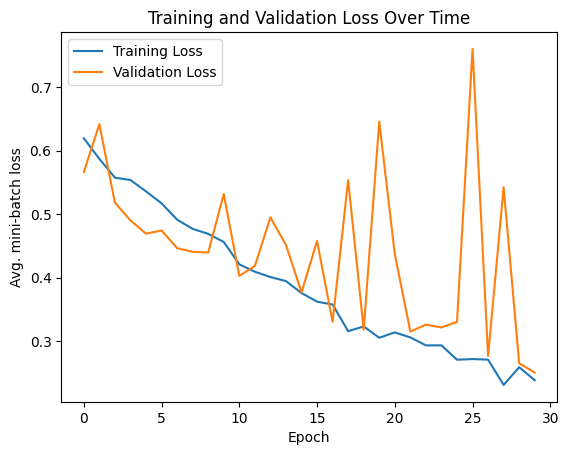

In [13]:
plt.plot(avg_losses, label='Training Loss')
plt.plot(avg_val_losses, label='Validation Loss')
plt.xlabel('mini-batch index / {}'.format(print_freq) if len(avg_losses) > len(avg_val_losses) else 'Epoch')
plt.ylabel('Avg. mini-batch loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## Testing




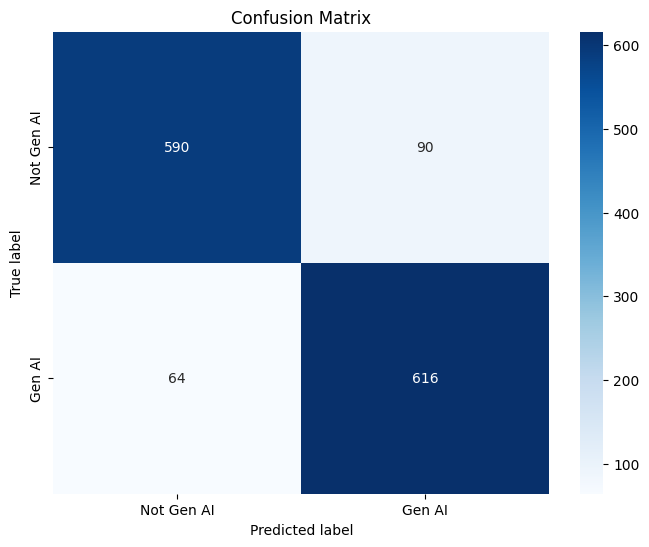

In [14]:
# confusion matrix
all_labels = []
all_predictions = []

with torch.no_grad():
    for spectrograms, labels in test_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        if spectrograms.shape[1] > 1:
            spectrograms = torch.mean(spectrograms, dim = 1, keepdim = True)

        outputs = model(spectrograms)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'g', cmap = 'Blues', xticklabels = ['Not Gen AI', 'Gen AI'], yticklabels = ['Not Gen AI', 'Gen AI'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
# accuracy
tn, fp, fn, tp = cm.ravel()
accuracy_from_cm = (tn + tp) / (tn + fp + fn + tp)
print(f"Accuracy from Confusion Matrix: {accuracy_from_cm * 100:.2f}%")

Accuracy from Confusion Matrix: 88.68%


# Save Model
After training and testing AudioCNN, the model is saved into the local environment, the computer environment, and Google Drive (better safe than sorry). The code to load the model later is also shown.  

In [17]:
torch.save(model.state_dict(), "FINAL_AI_MUSIC_DETECTOR.pth")
files.download("FINAL_AI_MUSIC_DETECTOR.pth")
torch.save(model.state_dict(), "/content/drive/MyDrive/FINAL_AI_MUSIC_DETECTOR.pth")

# load the model
loaded_model = AudioCNN()
loaded_model.load_state_dict(torch.load("FINAL_AI_MUSIC_DETECTOR.pth"))
loaded_model.to(device)  # Move the model to the appropriate device
loaded_model.eval()      # Set the model to evaluation mode

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

AudioCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (avg_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)